# Store Sales Forecasting Day 4: Advanced Modeling
**Goal:** Go from baseline (0.40562) to top 15% using lag features, rolling windows, and an LightGBM + XGBoost ensemble.

**What this notebook does:**
1. Load `train_fe.csv` / `test_fe.csv` from Day 3
2. Build powerful lag & rolling-window time-series features
3. Train LightGBM (tuned) + XGBoost models
4. Ensemble predictions (weighted average)
5. Generate final `submission.csv`
6. Save `feature_importance.png` and `model_comparison.csv` to `../outputs/`
**Input:** `../data/train_fe.csv` | `../data/test_fe.csv` 
**Output:** `../submissions/submission_advanced.csv`  
**Models:** `../models/lgbm_advanced.pkl` | `../models/xgb_advanced.pkl`

In [1]:
print("Import Libraries")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, os, time
warnings.filterwarnings('ignore')

import lightgbm as lgbm
import xgboost as xgb
from sklearn.metrics import mean_squared_log_error

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"LightGBM Version: {lgbm.__version__}")
print(f"XGBoost Version: {xgb.__version__}")

print("Success: Libraries imported")

Import Libraries


LightGBM Version: 4.6.0
XGBoost Version: 2.1.3
Success: Libraries imported


In [2]:
print("Load Data")

import gc
train = pd.read_csv('../data/train_fe.csv')
train['date'] = pd.to_datetime(train['date'])
test = pd.read_csv('../data/test_fe.csv')
test['date'] = pd.to_datetime(test['date'])

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Train dates: {train['date'].min()} to {train['date'].max()}")
print(f"Test dates: {test['date'].min()} to {test['date'].max()}")
print(f"Train columns: {train.columns.tolist()}")

print("Success: Data loaded")

Load Data
Train shape: (3000888, 69)
Test shape: (28512, 74)
Train dates: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Test dates: 2017-08-16 00:00:00 to 2017-08-31 00:00:00
Train columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'is_national_holiday', 'is_local_holiday', 'is_transferred_holiday', 'is_special_event', 'is_earthquake', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter', 'dayofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'is_payday', 'days_to_payday', 'store_type_enc', 'family_enc', 'city_enc', 'state_enc', 'store_closed', 'txn_count', 'sales_log', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_28', 'sales_lag_35', 'sales_lag_42', 'sales_lag_56', 'sales_lag_364', 'sales_lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_lw', 'rolling_std_lw', 'oi

In [3]:
print("Target Transformation")

train['sales_log'] = np.log1p(train['sales'])

print(f"sales_log - mean: {train['sales_log'].mean():.4f}, std: {train['sales_log'].std():.4f}, min: {train['sales_log'].min():.4f}, max: {train['sales_log'].max():.4f}")
print(f"Original sales - mean: {train['sales'].mean():.4f}, std: {train['sales'].std():.4f}, min: {train['sales'].min():.4f}, max: {train['sales'].max():.4f}")

print("Success: Target transformed")

Target Transformation
sales_log - mean: 2.9264, std: 2.6951, min: 0.0000, max: 11.7338
Original sales - mean: 357.7757, std: 1101.9977, min: 0.0000, max: 124717.0000
Success: Target transformed


In [4]:
print("Lag and Rolling Window features")

train = train.sort_values(['store_nbr', 'family', 'date']).reset_index(drop = True)
test = test.sort_values(['store_nbr', 'family', 'date']).reset_index(drop = True)

combined = pd.concat([train, test], sort = False).reset_index(drop = True)
combined = combined.sort_values(['store_nbr', 'family', 'date']).reset_index(drop = True)

grp = combined.groupby(['store_nbr', 'family'])

for lag in [7, 14, 16, 21, 28]:
    combined[f'sales_lag_{lag}'] = grp['sales_log'].shift(lag)
    print(f"  lag_{lag:2d}  — nulls: {combined[f'sales_lag_{lag}'].isna().sum():,}")

for window in [7, 14, 30]:
    combined[f'roll_mean_{window}'] = grp['sales_log'].transform(
        lambda x: x.shift(16).rolling(window, min_periods=1).mean()
    )
    combined[f'roll_std_{window}']  = grp['sales_log'].transform(
        lambda x: x.shift(16).rolling(window, min_periods=1).std().fillna(0)
    )
    combined[f'roll_max_{window}']  = grp['sales_log'].transform(
        lambda x: x.shift(16).rolling(window, min_periods=1).max()
    )
    print(f"  roll_{window:2d} mean/std/max created")

combined['ewm_alpha_07'] = grp['sales_log'].transform(
    lambda x: x.shift(16).ewm(alpha=0.7, adjust=False).mean()
)
combined['ewm_alpha_03'] = grp['sales_log'].transform(
    lambda x: x.shift(16).ewm(alpha=0.3, adjust=False).mean()
)
print("  EWM features created")

train = combined[combined['sales'].notna()].reset_index(drop=True)
test  = combined[combined['sales'].isna()].reset_index(drop=True)
print(f"\nPost-lag train: {train.shape}  test: {test.shape}")

print("Success: Lag and rolling features created")

Lag and Rolling Window features
  lag_ 7  — nulls: 28,512
  lag_14  — nulls: 28,512
  lag_16  — nulls: 28,512
  lag_21  — nulls: 37,422
  lag_28  — nulls: 49,896
  roll_ 7 mean/std/max created
  roll_14 mean/std/max created
  roll_30 mean/std/max created
  EWM features created

Post-lag train: (3000888, 88)  test: (28512, 88)
Success: Lag and rolling features created


In [5]:
print("Promotion Lag Features")
grp_full = combined.groupby(['store_nbr','family'])

combined['promo_lag_7']  = grp_full['onpromotion'].shift(7)
combined['promo_lag_14'] = grp_full['onpromotion'].shift(14)
combined['promo_roll7']  = grp_full['onpromotion'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).sum()
)

train = combined[combined['sales'].notna()].reset_index(drop=True)
test  = combined[combined['sales'].isna()].reset_index(drop=True)
print(f"Promotion lags added  — train: {train.shape}  test: {test.shape}")

print("Success: Promotion lag features created")

Promotion Lag Features
Promotion lags added  — train: (3000888, 90)  test: (28512, 90)
Success: Promotion lag features created


In [6]:
print("Define Feature Columns")

DROP_COLS = ['id','date','sales','sales_log','family','city','state','type']
FEATURES  = [c for c in train.columns if c not in DROP_COLS]

print(f"Total features : {len(FEATURES)}")
print("\nFeature list:")
for f in FEATURES:
    print(f"  {f}")

print("Success: Feature columns defined")

Define Feature Columns
Total features : 82

Feature list:
  store_nbr
  onpromotion
  cluster
  dcoilwtico
  is_national_holiday
  is_local_holiday
  is_transferred_holiday
  is_special_event
  is_earthquake
  year
  month
  day
  dayofweek
  weekofyear
  quarter
  dayofyear
  is_weekend
  is_month_start
  is_month_end
  is_payday
  days_to_payday
  store_type_enc
  family_enc
  city_enc
  state_enc
  store_closed
  txn_count
  month_sin
  month_cos
  dow_sin
  dow_cos
  sales_lag_7
  sales_lag_14
  sales_lag_21
  sales_lag_28
  sales_lag_35
  sales_lag_42
  sales_lag_56
  sales_lag_364
  sales_lag_365
  rolling_mean_7
  rolling_std_7
  rolling_mean_14
  rolling_std_14
  rolling_mean_28
  rolling_std_28
  rolling_mean_lw
  rolling_std_lw
  oil_lag7
  oil_lag14
  oil_rolling_mean_7
  days_to_next_hol
  days_since_last_hol
  sf_mean_sales
  sf_median_sales
  sf_std_sales
  sf_max_sales
  sf_dow_mean
  sf_month_mean
  sf_promo_ratio
  promo_roll7
  lag_list_7
  lag_list_14
  lag_list_21
 

In [7]:
print("Time-Based Train / Validation Split")
# Last 30 days of training data as validation
VAL_START = '2017-07-16'

trn_idx = train['date'] < VAL_START
val_idx = train['date'] >= VAL_START

val_dates = train.loc[val_idx, 'date']
val_min_date = val_dates.min().date()
val_max_date = val_dates.max().date()

X_trn, y_trn = train.loc[trn_idx, FEATURES].copy(), train.loc[trn_idx, 'sales_log'].copy()
X_val, y_val = train.loc[val_idx, FEATURES].copy(), train.loc[val_idx, 'sales_log'].copy()
X_tst = test[FEATURES].copy()

del train
del test
if 'combined' in globals():
    del combined
gc.collect()

print(f"Train rows : {len(X_trn):,}  |  Val rows: {len(X_val):,}  |  Test rows: {len(X_tst):,}")
print(f"Val period : {val_min_date} → {val_max_date}")

# Fill NaN from earliest lag rows
X_trn.fillna(0, inplace=True)
X_val.fillna(0, inplace=True)
X_tst.fillna(0, inplace=True)
print("NaN fill complete")

print("Success: Train/Val split done")


Time-Based Train / Validation Split
Train rows : 2,945,646  |  Val rows: 55,242  |  Test rows: 28,512
Val period : 2017-07-16 → 2017-08-15
NaN fill complete
Success: Train/Val split done


In [8]:
print("Evaluation Helper")

def rmsle(y_true, y_pred_log):
    """Both inputs are in log1p-space. Returns RMSLE in original sales space."""
    y_pred_log = np.clip(y_pred_log, 0, None)
    return np.sqrt(mean_squared_log_error(
        np.expm1(y_true),
        np.expm1(y_pred_log)
    ))

print(f"RMSLE(zeros): {rmsle(np.zeros(5), np.zeros(5)):.4f}  (should be 0.0)")

print("Success: Evaluation helper defined")

Evaluation Helper
RMSLE(zeros): 0.0000  (should be 0.0)
Success: Evaluation helper defined


In [9]:
print("LightGBM Advanced Model")

lgbm_params = {
    'objective'        : 'regression_l1',   # MAE — robust to outliers
    'metric'           : 'rmse',
    'learning_rate'    : 0.05,
    'num_leaves'       : 128,
    'max_depth'        : -1,
    'min_child_samples': 20,
    'feature_fraction' : 0.80,
    'bagging_fraction' : 0.80,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 0.1,
    'verbose'          : -1,
    'n_jobs'           : -1,
    'seed'             : 42,
}

dtrain = lgbm.Dataset(X_trn, label=y_trn)
dval   = lgbm.Dataset(X_val, label=y_val, reference=dtrain)

t0 = time.time()
lgbm_model = lgbm.train(
    lgbm_params,
    dtrain,
    num_boost_round = 2000,
    valid_sets      = [dval],
    callbacks       = [
        lgbm.early_stopping(stopping_rounds=50, verbose=False),
        lgbm.log_evaluation(period=100)
    ]
)
elapsed = time.time() - t0

val_pred_lgbm = lgbm_model.predict(X_val)
lgbm_rmsle    = rmsle(y_val, val_pred_lgbm)

print(f"\nLightGBM training time : {elapsed:.1f}s")
print(f"Best iteration         : {lgbm_model.best_iteration}")
print(f"Validation RMSLE       : {lgbm_rmsle:.5f}")

with open('../models/lgbm_advanced.pkl','wb') as f:
    pickle.dump(lgbm_model, f)
print("Model saved → ../models/lgbm_advanced.pkl")

print("Success: LightGBM Model Trained")

LightGBM Advanced Model
[100]	valid_0's rmse: 0.399049
[200]	valid_0's rmse: 0.387697
[300]	valid_0's rmse: 0.386453
[400]	valid_0's rmse: 0.383495
[500]	valid_0's rmse: 0.381953
[600]	valid_0's rmse: 0.381266
[700]	valid_0's rmse: 0.380612
[800]	valid_0's rmse: 0.380049
[900]	valid_0's rmse: 0.379392
[1000]	valid_0's rmse: 0.378969
[1100]	valid_0's rmse: 0.378717
[1200]	valid_0's rmse: 0.378551

LightGBM training time : 859.3s
Best iteration         : 1167
Validation RMSLE       : 0.37850
Model saved → ../models/lgbm_advanced.pkl
Success: LightGBM Model Trained


Feature Importance Plot


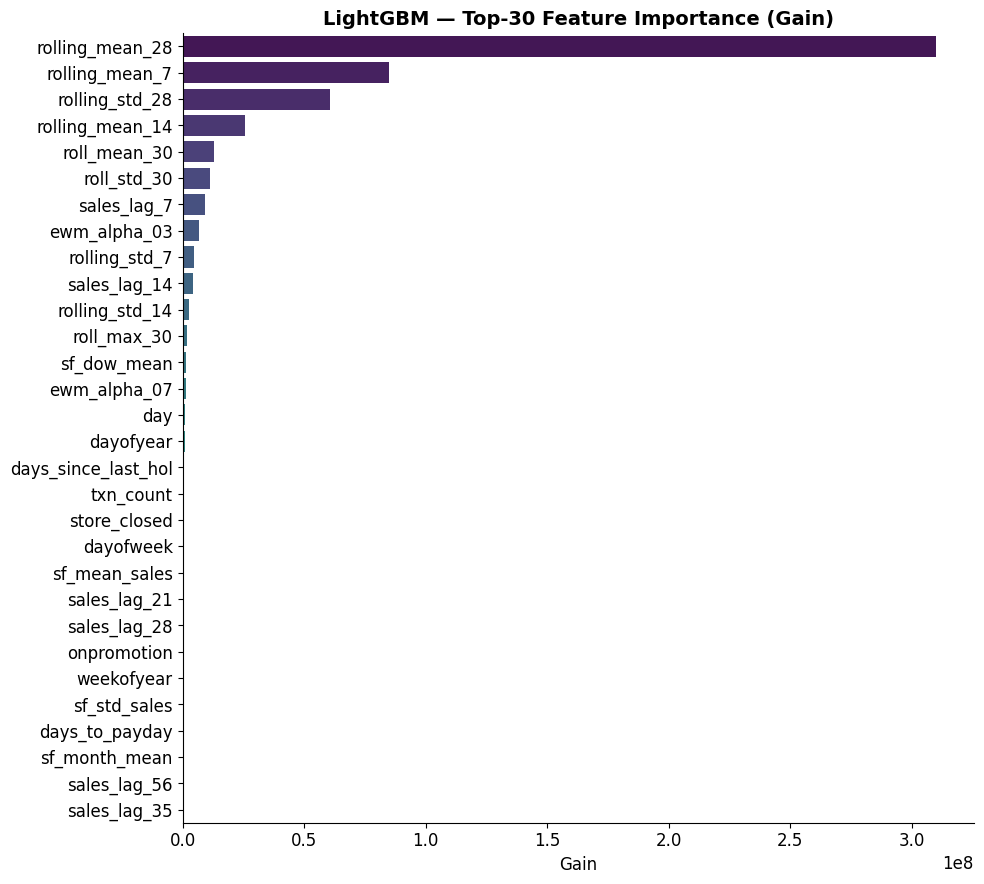

Saved → ../outputs/feature_importance.png
Success: Feature Importance Plot created


In [10]:
print("Feature Importance Plot")

importance_df = pd.DataFrame({
    'feature'   : lgbm_model.feature_name(),
    'importance': lgbm_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('LightGBM — Top-30 Feature Importance (Gain)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gain')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/feature_importance.png")

print("Success: Feature Importance Plot created")

In [12]:
print("XGBoost Advanced Model")

import gc
import time
import pickle
# 1. Downcast to float32 to save ~50% memory before DMatrix creation
for df in [X_trn, X_val, X_tst]:
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = df[col].astype('int32')
gc.collect()

xgb_params = {
    'objective'        : 'reg:squarederror',
    'eval_metric'      : 'rmse',
    'learning_rate'    : 0.05,
    'max_depth'        : 7,
    'min_child_weight' : 20,
    'subsample'        : 0.80,
    'colsample_bytree' : 0.80,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'seed'             : 42,
    'tree_method'      : 'hist', # 'hist' is very memory efficient
    'verbosity'        : 0,
}

# 2. Create DMatrix iteratively and delete test DMatrix until later
dmatrix_trn = xgb.DMatrix(X_trn, label=y_trn)
dmatrix_val = xgb.DMatrix(X_val, label=y_val)
# We delay creating dmatrix_tst until we actually need predictions!

t0 = time.time()
xgb_model = xgb.train(
    xgb_params,
    dmatrix_trn,
    num_boost_round       = 2000,
    evals                 = [(dmatrix_trn,'train'), (dmatrix_val,'val')],
    early_stopping_rounds = 50,
    verbose_eval          = 100
)
elapsed = time.time() - t0

val_pred_xgb = xgb_model.predict(dmatrix_val)
xgb_rmsle    = rmsle(y_val, val_pred_xgb)

print(f"\nXGBoost training time  : {elapsed:.1f}s")
print(f"Best iteration         : {xgb_model.best_iteration}")
print(f"Validation RMSLE       : {xgb_rmsle:.5f}")

# 3. Immediately free up training DMatrix memory once done
del dmatrix_trn
del dmatrix_val
gc.collect()

import os
os.makedirs('../models', exist_ok=True)
with open('../models/xgb_advanced.pkl','wb') as f:
    pickle.dump(xgb_model, f)
print("Model saved: ../models/xgb_advanced.pkl")

print("Success: XGBoost Model Trained")


XGBoost Advanced Model
[0]	train-rmse:2.56570	val-rmse:2.50018
[100]	train-rmse:0.38152	val-rmse:0.38625
[200]	train-rmse:0.36435	val-rmse:0.38073
[300]	train-rmse:0.35668	val-rmse:0.37783
[400]	train-rmse:0.35168	val-rmse:0.37601
[500]	train-rmse:0.34800	val-rmse:0.37435
[600]	train-rmse:0.34509	val-rmse:0.37316
[700]	train-rmse:0.34271	val-rmse:0.37239
[800]	train-rmse:0.34065	val-rmse:0.37167
[900]	train-rmse:0.33884	val-rmse:0.37123
[1000]	train-rmse:0.33718	val-rmse:0.37077
[1100]	train-rmse:0.33565	val-rmse:0.37041
[1200]	train-rmse:0.33425	val-rmse:0.37010
[1300]	train-rmse:0.33288	val-rmse:0.36986
[1400]	train-rmse:0.33157	val-rmse:0.36951
[1500]	train-rmse:0.33034	val-rmse:0.36933
[1600]	train-rmse:0.32917	val-rmse:0.36915
[1700]	train-rmse:0.32796	val-rmse:0.36897
[1800]	train-rmse:0.32686	val-rmse:0.36891
[1900]	train-rmse:0.32585	val-rmse:0.36880
[1999]	train-rmse:0.32476	val-rmse:0.36869

XGBoost training time  : 1406.5s
Best iteration         : 1998
Validation RMSLE      

In [13]:
print("Ensemble (Weighted Average)")

# Weight inversely proportional to RMSLE — lower error = higher weight
w_lgb = 1 / lgbm_rmsle
w_xgb = 1 / xgb_rmsle
w_tot = w_lgb + w_xgb
w_lgb /= w_tot
w_xgb /= w_tot

print(f"LightGBM weight : {w_lgb:.4f}  (RMSLE {lgbm_rmsle:.5f})")
print(f"XGBoost  weight : {w_xgb:.4f}  (RMSLE {xgb_rmsle:.5f})")

val_pred_ens = w_lgb * val_pred_lgbm + w_xgb * val_pred_xgb
ens_rmsle    = rmsle(y_val, val_pred_ens)
print(f"Ensemble  RMSLE : {ens_rmsle:.5f}")

Ensemble (Weighted Average)
LightGBM weight : 0.4934  (RMSLE 0.37850)
XGBoost  weight : 0.5066  (RMSLE 0.36869)
Ensemble  RMSLE : 0.37061


In [15]:
print("Model Comparison Table")

baseline_rmsle = 0.40562  

results = pd.DataFrame({
    'Model'     : ['Baseline LGBM (Day 3)', 'LightGBM Advanced', 'XGBoost Advanced', 'Ensemble'],
    'Val_RMSLE' : [baseline_rmsle, lgbm_rmsle, xgb_rmsle, ens_rmsle],
    'Delta'     : [0,
                   lgbm_rmsle - baseline_rmsle,
                   xgb_rmsle - baseline_rmsle,
                   ens_rmsle - baseline_rmsle]
})

results.to_csv('../outputs/model_comparison.csv', index=False)
print(results.to_string(index=False))
print("\nSaved: ../outputs/model_comparison.csv")

Model Comparison Table
                Model  Val_RMSLE   Delta
Baseline LGBM (Day 3)     0.4056  0.0000
    LightGBM Advanced     0.3785 -0.0271
     XGBoost Advanced     0.3687 -0.0369
             Ensemble     0.3706 -0.0350

Saved: ../outputs/model_comparison.csv


Model Comparison Bar Chart


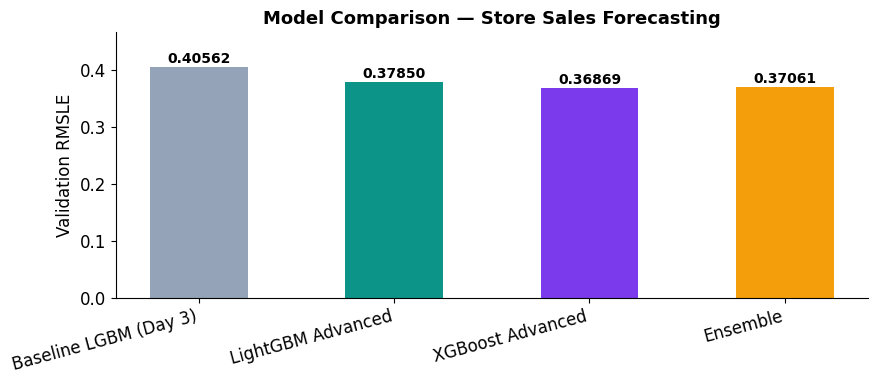

Saved: ../outputs/model_comparison_chart.png


In [16]:
print("Model Comparison Bar Chart")

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#94a3b8','#0d9488','#7c3aed','#f59e0b']
bars   = ax.bar(results['Model'], results['Val_RMSLE'], color=colors, width=0.5)

for bar, val in zip(bars, results['Val_RMSLE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.5f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Validation RMSLE')
ax.set_title('Model Comparison — Store Sales Forecasting', fontsize=13, fontweight='bold')
ax.set_ylim(0, results['Val_RMSLE'].max() * 1.15)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../outputs/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/model_comparison_chart.png")

In [18]:
print("Generate Test Predictions")

tst_pred_lgb = lgbm_model.predict(X_tst)
tst_pred_xgb = xgb_model.predict(dmatrix_tst)

# Weighted ensemble
tst_pred_ens = w_lgb * tst_pred_lgb + w_xgb * tst_pred_xgb
tst_pred_ens = np.clip(tst_pred_ens, 0, None)   # no negative sales

# Inverse log1p back to original sales scale
tst_sales = np.expm1(tst_pred_ens)

# Zero out permanently closed stores
if 'store_closed' in test.columns:
    tst_sales[test['store_closed'] == 1] = 0
    print(f"Zeroed {(test['store_closed']==1).sum():,} closed-store rows")

print(f"Prediction stats — min: {tst_sales.min():.2f}  mean: {tst_sales.mean():.2f}  max: {tst_sales.max():.2f}")

Generate Test Predictions


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: lag_list_7: object, lag_list_14: object, lag_list_21: object, lag_list_28: object, lag_list_35: object, lag_list_42: object, lag_list_56: object